In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import hces
import matplotlib.font_manager as fm

fm.fontManager.addfont('/home/jaidevd/.local/share/fonts/Lora-Bold.ttf')
fm.fontManager.addfont('/home/jaidevd/.local/share/fonts/Lora-Regular.ttf')

df = pd.read_parquet('data/main.parquet')
df['Food'] = df[hces.FOOD_COLS].sum(axis=1)

hces.EDU_COLS = ['books'] + hces.EDU_COLS[2:]
df['Education'] = df[hces.EDU_COLS].sum(axis=1)

df['treat'].replace({True: "Beneficiaries", False: "Non-beneficiaries"}, inplace=True)

df[['treat', 'scheme', 'Food', 'Education']].head()
xdf = df[['treat', 'scheme', 'Food', 'Education']].copy()

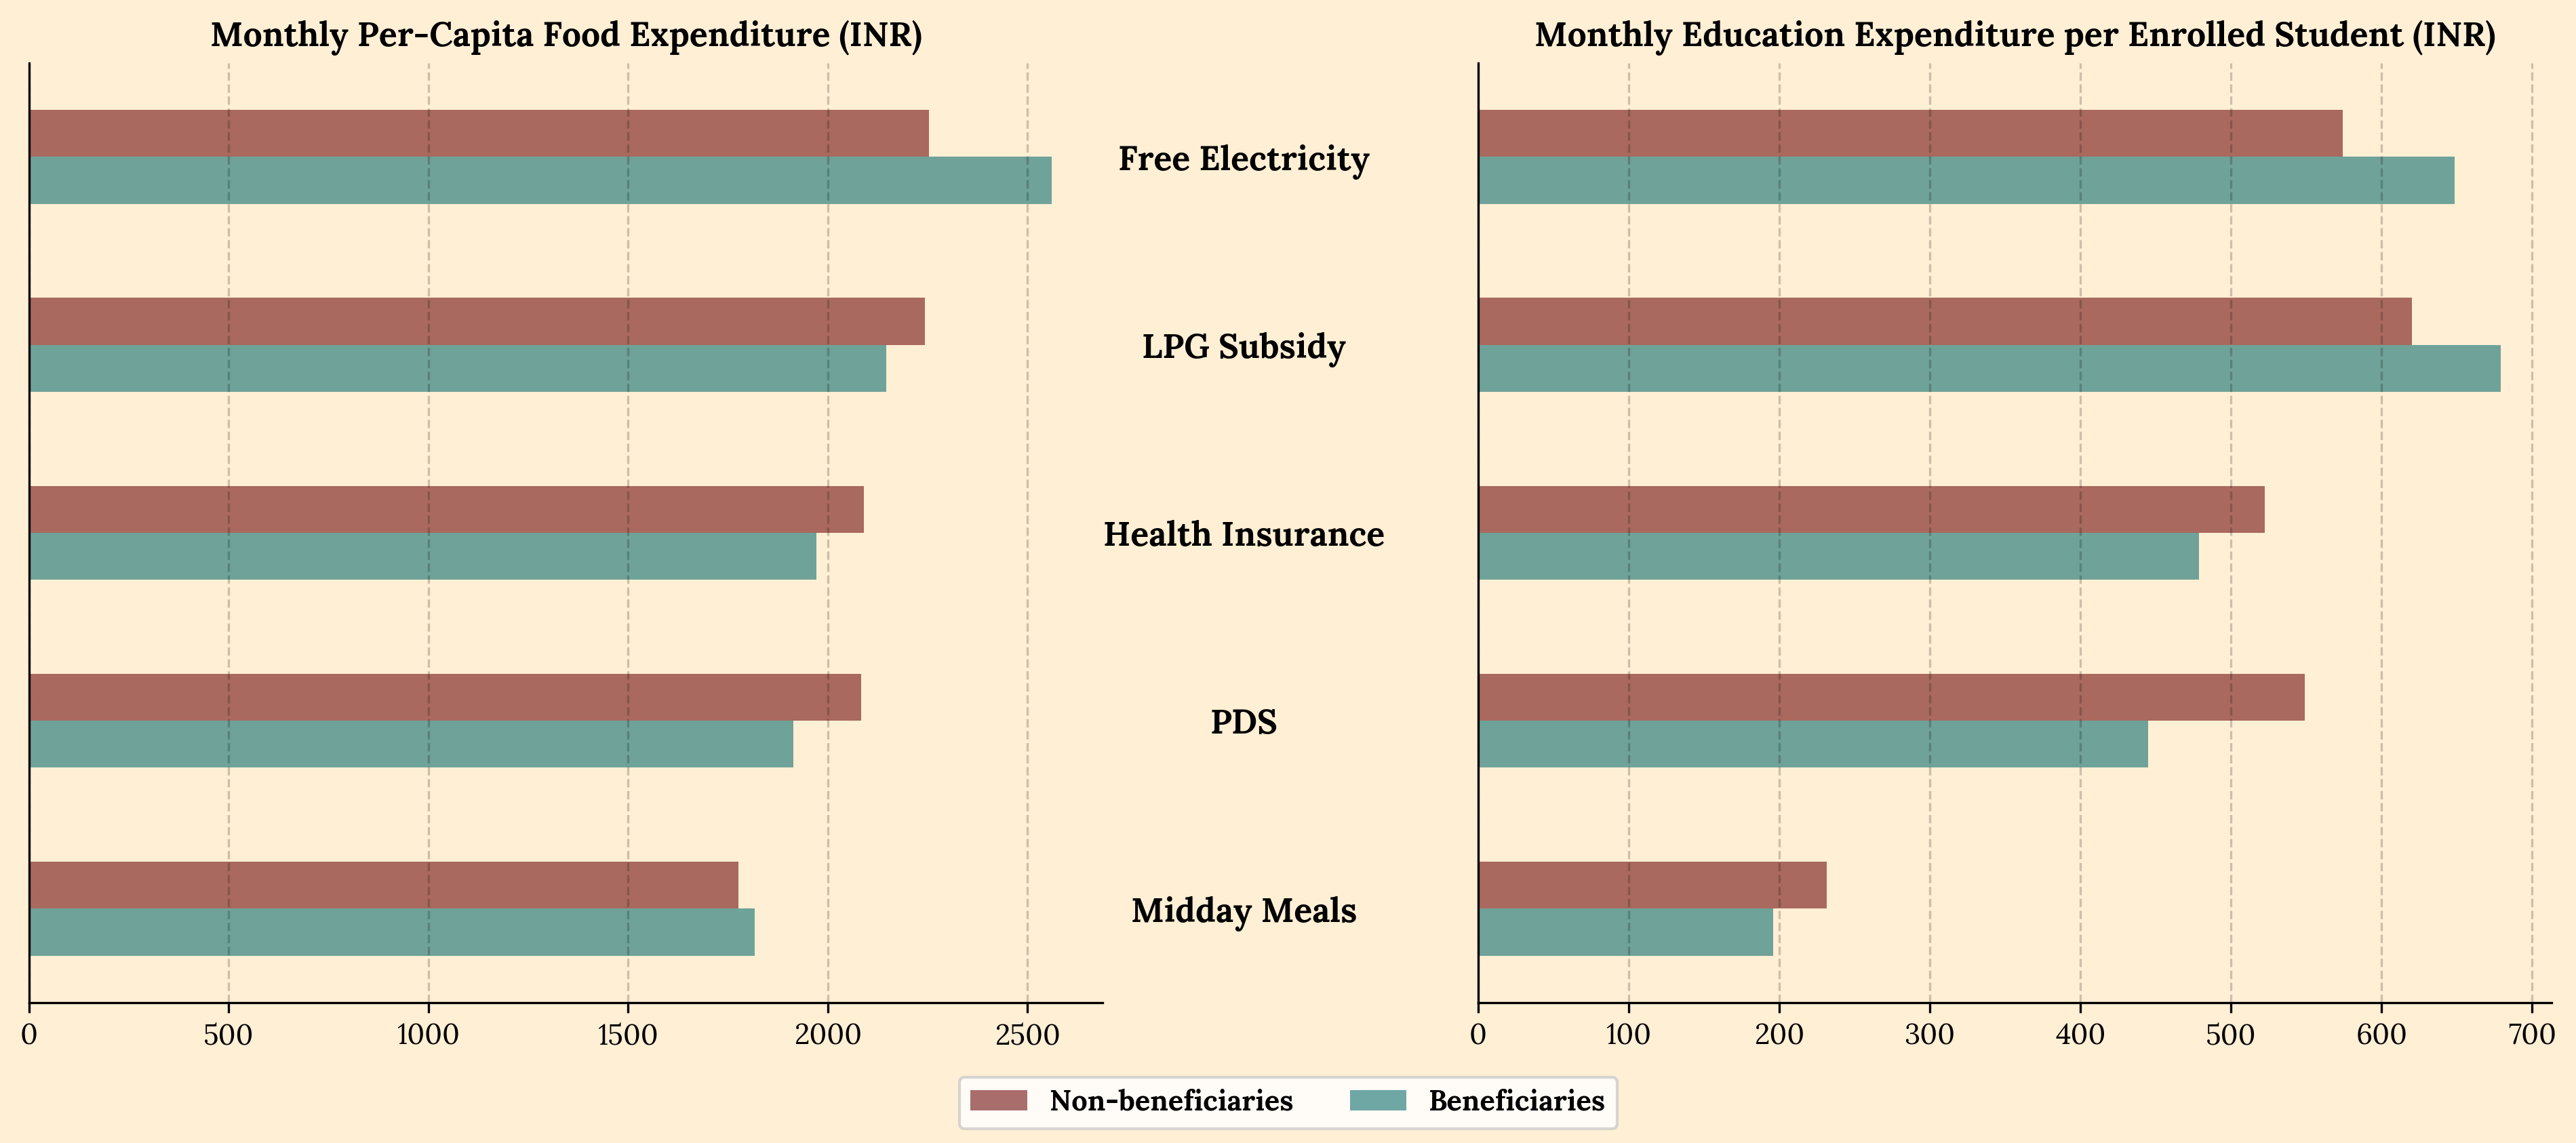

In [2]:
xx = pd.crosstab(index=xdf['treat'], columns=xdf['scheme'], values=xdf['Food'], aggfunc=lambda x: x)
scheme_order = ['Free Electricity', 'LPG Subsidy', 'Health Insurance', 'PDS', 'Midday Meals']


fig, (ax_left, ax_right) = plt.subplots(
    ncols=2,
    sharey=True,
    figsize=(16, 6),              # make figure wider
    gridspec_kw={"wspace": 0.35}, # increase space between plots
    dpi=300
)

# --- Left: Food ---
sns.barplot(
    data=df,
    y="scheme",
    x="Food",
    hue="treat",
    order=scheme_order,
    orient="h",
    ax=ax_left,
    palette={'Beneficiaries': 'teal', 'Non-beneficiaries': 'maroon'},
    alpha=0.6,
    width=0.5
)

ax_left.set_title("Monthly Per-Capita Food Expenditure (INR)", fontfamily="Lora", fontweight="bold")
ax_left.set_ylabel("")


# Move scheme labels to the middle
ax_left.yaxis.tick_right()
ax_left.tick_params(axis="y", length=0, pad=50)


# Right-align labels so they sit nicely between plots
for label in ax_left.get_yticklabels():
    label.set_horizontalalignment("center")
    label.set_fontfamily('Lora')
    label.set_fontweight('bold')
    label.set_fontsize(12)


# --- Right: Education ---
sns.barplot(
    data=df,
    y="scheme",
    x="Education",
    hue="treat",
    order=scheme_order,
    orient="h",
    ax=ax_right,
    palette={'Beneficiaries': 'teal', 'Non-beneficiaries': 'maroon'},
    alpha=0.6, width=0.5
)

ax_right.set_title("Monthly Education Expenditure per Enrolled Student (INR)", fontfamily="Lora", fontweight="bold")
# ax_right.set_xlabel("Education")
ax_right.set_ylabel("")
ax_right.tick_params(axis="y", left=False, labelleft=False)


handles, labels = ax_left.get_legend_handles_labels()
fig.legend(handles, labels, title=None, loc="lower center", ncol=2, prop={'family': 'Lora', 'weight': 'bold'})

fig.set_facecolor('papayawhip')

for a in (ax_left, ax_right):
    a.set_facecolor('papayawhip')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(axis='x', linestyle='dashed', color='k', alpha=0.2)
    a.legend_.remove()
    a.set_xlabel('')
    a.tick_params(axis="x", labelfontfamily='Lora')

In [3]:
FOOD_COLS = ['Cereals', 'Pulses', 'Sugar & Salt', 'Dairy', 'Vegetables', 'Fruits', 'Eggs, Fish & Meat', 'Oil', 'Spices', 'Beverages', 'Served Food', 'Processed Food']
fcmapper = {k: v for k, v in zip(hces.FOOD_COLS, FOOD_COLS)}
ecmapper = {k: v for k, v in zip(hces.EDU_COLS, ['Books', 'Stationery', 'Fees', 'Coaching', 'Other'])}

df.rename(fcmapper, axis=1, inplace=True)
df.rename(ecmapper, axis=1, inplace=True)

In [10]:
xdf = df[df['scheme'] == 'LPG Subsidy'][['treat', 'Books', 'Stationery', 'Fees', 'Coaching', 'Other']]
xdf.set_index('treat', inplace=True)
xdf.loc['Beneficiaries'] - xdf.loc['Non-beneficiaries']

Books          8.964395
Stationery     9.814849
Fees           1.678999
Coaching      41.193033
Other         -3.073984
dtype: float64

/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lo

Other         -3.073984
Fees           1.678999
Books          8.964395
Stationery     9.814849
Coaching      41.193033
dtype: float64


/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
/tmp/ipykernel_14040/451549345.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lo

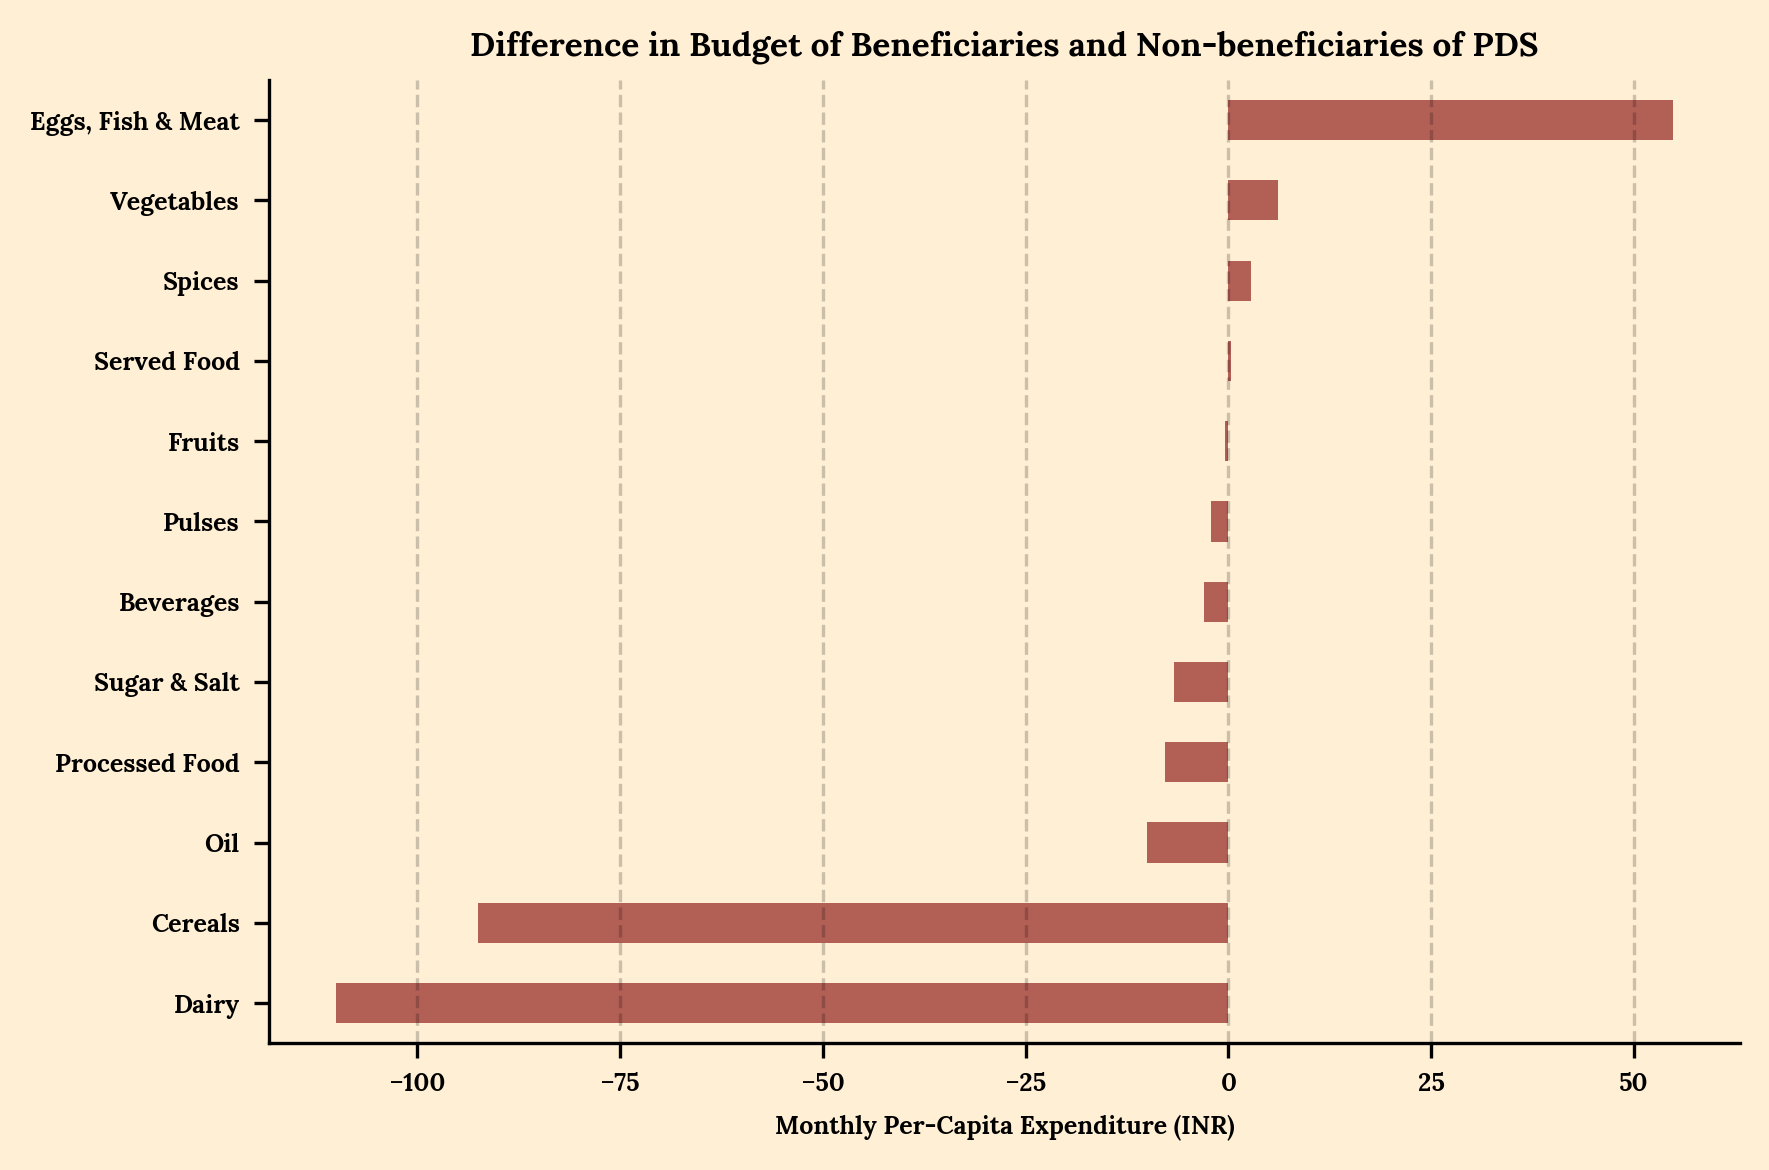

In [12]:
# fig, ax = plt.subplots(nrows=5, ncols=2, dpi=300, figsize=(12, 12))

for i, (scheme, group) in enumerate(df.groupby('scheme')):
    xdf = group.set_index('treat')
    
    for cat, colmapper in {'Education': ecmapper, 'Food': fcmapper}.items():
        plt.close('all')
        cat_df = xdf[colmapper.values()]
        ddf = (cat_df.loc['Beneficiaries'] - cat_df.loc['Non-beneficiaries']).sort_values()
        if cat == 'Education' and scheme == "LPG Subsidy":
            print(ddf)
        
        fig, ax = plt.subplots(dpi=300, figsize=(6, 4))
        ddf.plot(kind='barh', ax=ax, color="maroon", alpha=0.6)
        ax.yaxis.set_ticklabels(ax.yaxis.get_ticklabels(), fontsize=6, fontfamily='Lora', fontweight='bold')
        ax.set_title(f'Difference in Budget of Beneficiaries and Non-beneficiaries of {scheme}', fontsize=8, fontfamily="Lora", fontweight="bold")
        if cat == "Food":
            ax.set_xlabel('Monthly Per-Capita Expenditure (INR)', fontsize=6, fontfamily="Lora", fontweight="bold")
        else:
            ax.set_xlabel('Monthly Household Expenditure per Enrolled Student (INR)', fontsize=6, fontfamily="Lora", fontweight="bold")
        ax.set_facecolor('papayawhip')
        ax.grid(axis='x', linestyle='dashed', color='k', alpha=0.2)
        ax.set_xticklabels(ax.get_xticklabels(), fontfamily='Lora', fontweight='bold', fontsize=6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        fig.set_facecolor('papayawhip')
        plt.tight_layout()
        plt.savefig(f"assets/{scheme}-{cat}.png")

In [8]:
scheme

'Free Electricity'